In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

In [17]:
def epsilon_greedy(Q, state, nA, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(nA)
    else:
        return np.argmax(Q[state])


def plot_returns(returns_sarsa, returns_q, falls_sarsa, falls_q):
    plt.figure(figsize=(14, 5))

    # Returns
    plt.subplot(1, 2, 1)
    plt.plot(np.mean(returns_sarsa, axis=0), label="SARSA")
    plt.plot(np.mean(returns_q, axis=0), label="Q-learning")
    plt.xlabel("Episode")
    plt.ylabel("Average Return")
    plt.title("Average Return vs Episode")
    plt.legend()

    # Falls
    plt.subplot(1, 2, 2)
    plt.plot(np.mean(falls_sarsa, axis=0), label="SARSA")
    plt.plot(np.mean(falls_q, axis=0), label="Q-learning")
    plt.xlabel("Episode")
    plt.ylabel("Cliff Falls")
    plt.title("Cliff Falls vs Episode")
    plt.legend()

    plt.show()


def plot_policy(Q, env, title):
    nrow, ncol = env.unwrapped.shape  # (4, 12) for CliffWalking
    nS = env.observation_space.n
    actions = np.array(['←','↓','→','↑'])
    policy_grid = np.chararray((nrow, ncol), unicode=True)

    # derive special states
    start_state = (nrow - 1) * ncol  # bottom-left index
    goal_state = nrow * ncol - 1     # bottom-right index
    cliff = [s for s in range(start_state + 1, goal_state)]

    for s in range(nS):
        y, x = divmod(s, ncol)
        if s == start_state:
            policy_grid[y, x] = 'S'
        elif s == goal_state:
            policy_grid[y, x] = 'G'
        elif s in cliff:
            policy_grid[y, x] = 'C'
        else:
            best_a = np.argmax(Q[s])
            policy_grid[y, x] = actions[best_a]

    print("\n" + title)
    for row in policy_grid:
        print(' '.join(row))


In [18]:
def train(env, episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1, method="sarsa"):
    nA = env.action_space.n
    nS = env.observation_space.n
    Q = np.zeros((nS, nA))

    returns = []
    falls = []

    for ep in range(episodes):
        state, _ = env.reset()
        action = epsilon_greedy(Q, state, nA, epsilon)
        done = False
        total_reward = 0
        cliff_fall = 0

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if reward == -100:
                cliff_fall += 1

            total_reward += reward

            if method == "sarsa":
                next_action = epsilon_greedy(Q, next_state, nA, epsilon)
                td_target = reward + gamma * Q[next_state, next_action] * (not done)
            elif method == "qlearning":
                td_target = reward + gamma * np.max(Q[next_state]) * (not done)
            else:
                raise ValueError("Method must be 'sarsa' or 'qlearning'")

            Q[state, action] += alpha * (td_target - Q[state, action])
            state = next_state

            if method == "sarsa":
                action = next_action
            else:
                action = epsilon_greedy(Q, state, nA, epsilon)

        returns.append(total_reward)
        falls.append(cliff_fall)

    return Q, returns, falls


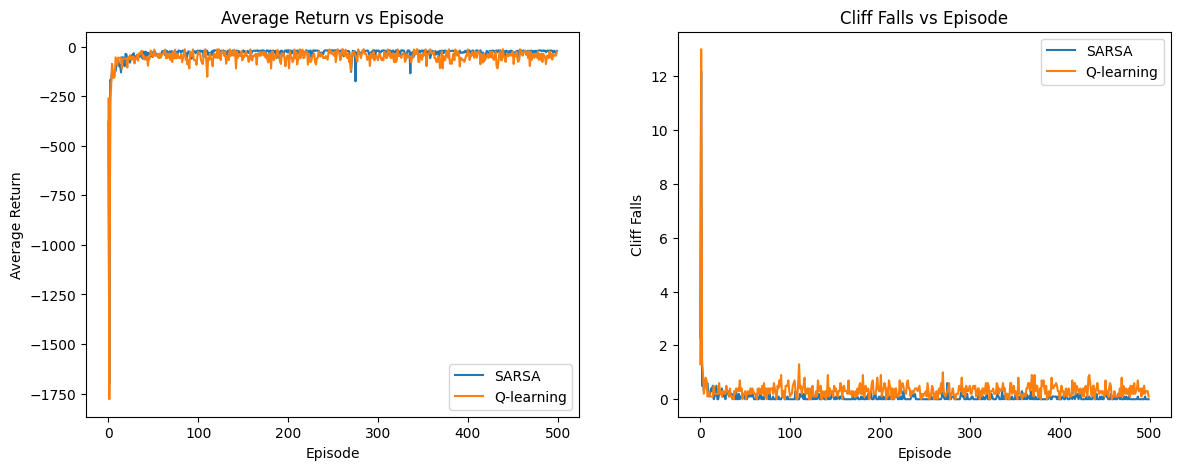


Final SARSA Policy
↓ ↓ ↓ ↓ ↓ ↓ ← → ↓ ↓ → ↑
← ← ← ↓ ↓ ← ← ← ← ← ↓ →
← ← ← ← ↓ ← ← ← ← ← ↓ →
S C C C C C C C C C C G

Final Q-learning Policy
↑ ↓ ↓ ↓ ↓ ↓ ← ↓ → → ↓ →
↓ ↓ ↓ → → → → → ↓ → → →
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ →
S C C C C C C C C C C G


/tmp/ipython-input-1093395533.py:36: DeprecationWarning: `np.chararray` is deprecated and will be removed from the main namespace in the future. Use an array with a string or bytes dtype instead.
  policy_grid = np.chararray((nrow, ncol), unicode=True)


In [19]:
env = gym.make("CliffWalking-v1")

runs = 10
episodes = 500

returns_sarsa, returns_q = [], []
falls_sarsa, falls_q = [], []

for _ in range(runs):
    Q_sarsa, r_sarsa, f_sarsa = train(env, episodes=episodes, method="sarsa")
    Q_q, r_q, f_q = train(env, episodes=episodes, method="qlearning")

    returns_sarsa.append(r_sarsa)
    returns_q.append(r_q)
    falls_sarsa.append(f_sarsa)
    falls_q.append(f_q)

# Plot results
plot_returns(np.array(returns_sarsa), np.array(returns_q), np.array(falls_sarsa), np.array(falls_q))

# Show final greedy policies
plot_policy(Q_sarsa, env.unwrapped, "Final SARSA Policy")
plot_policy(Q_q, env.unwrapped, "Final Q-learning Policy")
